## Part d

In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt 

### Inital condition for part d

In [2]:
# defining inital condition 
def u_initial(x):
    return np.exp(np.cos(x))

### Defining the Backward Euler Method

In [3]:
# defining the Backward euler method
def BE(u0, dt, num_tsteps, N, kx):

    # fourier transform of inital condition
    u_fourier = np.fft.fft(u0)

    # defining the coefficient for BE for given problem
    def coefficient(dt, k):
        return 1/(1 + dt * k**2)
    
    for i in range(num_tsteps):
        for k in range(N):
            u_fourier[k] = coefficient(dt, kx[k]) * u_fourier[k] 

    # taking inverse fourier transform to obtain the solution
    ut = np.fft.ifft(u_fourier)        

    return ut  

### Defining the Crank Nicolson Method

In [4]:
# defining the Backward euler method
def Crank_Nicolson(u0, dt, num_tsteps, N, kx):

    # fourier transform of inital condition
    u_fourier = np.fft.fft(u0)

    # defining the coefficient for BE for given problem
    def coefficient_cn(dt, k):
        return (2 -  dt * k**2) /(2 +  dt * k**2)
    
    for i in range(num_tsteps):
        for k in range(N):
            u_fourier[k] = coefficient_cn(dt, kx[k]) * u_fourier[k] 

    # taking inverse fourier transform to obtain the solution
    ut = np.fft.ifft(u_fourier)        

    return ut  

#### Calculating the exact solution 

In [5]:
# defining the parameters for calculation of exact solution 
T = 1              # length of time domain
L = 2 * np.pi      # length of spatial domain
N = 1024           # number of spectral points
nt_max = 10000     # discretization points of time domain for approximating exact solution
dt = T / nt_max    # spacing in time domain 
x = np.linspace(-L/2, L/2, N + 1)          # creating spatial points array for fourier transform   
x = x[: -1]                                # removing the last point to keep points equal to N               
kx = (2 * np.pi / L) * np.concatenate((np.arange(0, N // 2), np.arange(-N // 2, 0)))     # calculation of corresponding wave numbers 

u0 = u_initial(x)                 # initial condition in fourier space
xt = np.linspace(0, L, N + 1)     # discritized points in real space
xt = xt[:-1]


#### Calculations using BE

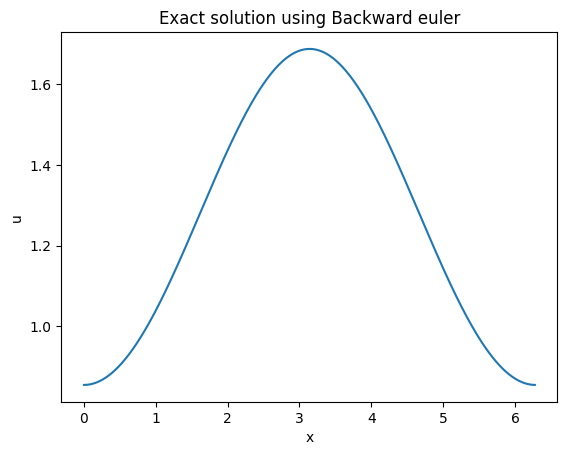

Backward Euler Errors: [0.047250017207980874, 0.023427734276244803, 0.011484971820320418, 0.005505654668749402]
Convergence Rates (Backward Euler): [array([], dtype=float64), 1.0120974185367988, 1.0284701193075831, 1.0607612892006697]


In [6]:
# calling the backward euler function to calculate solution
ut_exact = BE(u0, dt, nt_max, N, kx) 

# plotting the exact solution 
plt.plot(xt, np.real(ut_exact))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Exact solution using Backward euler')
plt.show()

# convergence study 
errors = []
prev_errors = []
convergence_rates = []

for nt in [100, 200, 400, 800]:
    dt = T / nt
    ut_be = BE(u0, dt, nt, N, kx)
    error_norm = np.linalg.norm(ut_be - ut_exact)
    errors.append(error_norm)
    
    if prev_errors != 0:
        convergence_rate = np.log(prev_errors / error_norm) / np.log(2)
        convergence_rates.append(convergence_rate)
    
    prev_errors = error_norm

print("Backward Euler Errors:", errors)
print("Convergence Rates (Backward Euler):", convergence_rates)


#### Calculation using Crank Nicolson

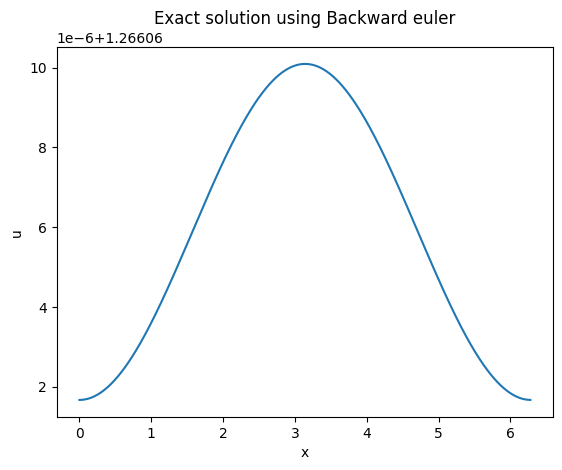

Crank Nicolson Errors: [9.409449653891146, 9.409508994428805, 9.409523829450071, 9.409527538196969]
Convergence Rates (Crank Nicolson): [array([], dtype=float64), -9.098303578268093e-06, -2.2745495810689245e-06, -5.686355440140188e-07]


In [7]:
# calling the Crank Nicolson function to calculate solution
ut_exact = Crank_Nicolson(u0, dt, nt_max, N, kx) 

# plotting the exact solution 
plt.plot(xt, np.real(ut_exact))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Exact solution using Backward euler')
plt.show()

# convergence study 
errors = []
prev_errors = []
convergence_rates = []

for nt in [100, 200, 400, 800]:
    dt = T / nt
    ut_be = Crank_Nicolson(u0, dt, nt, N, kx)
    error_norm = np.linalg.norm(ut_be - ut_exact)
    errors.append(error_norm)
    
    if prev_errors != 0:
        convergence_rate = np.log(prev_errors / error_norm) / np.log(2)
        convergence_rates.append(convergence_rate)
    
    prev_errors = error_norm

print("Crank Nicolson Errors:", errors)
print("Convergence Rates (Crank Nicolson):", convergence_rates)


## Part e

In [8]:
# definging the initial conditions
def u_initial_e(x):
    u = np.zeros_like(x)
    for i in range(len(x)):
        x0 = (i * L / len(x)) - np.pi
        if x0 < -np.pi / 2 or x0 > np.pi / 2:
            u[i] = 1.0
        else:
            u[i] = 0.0
    return u

### Backward euler

In [9]:
# defining the Backward euler method
def BE(u0, dt, num_tsteps, N, kx):

    # fourier transform of inital condition
    u_fourier = np.fft.fft(u0)

    # defining the coefficient for BE for given problem
    def coefficient(dt, k):
        return 1/(1 + dt * k**2)
    
    for i in range(num_tsteps):
        for k in range(N):
            u_fourier[k] = coefficient(dt, kx[k]) * u_fourier[k] 

    # taking inverse fourier transform to obtain the solution
    ut = np.fft.ifft(u_fourier)        

    return ut  

In [10]:
# defining the parameters for calculation of exact solution 
T = 1              # length of time domain
L = 2 * np.pi      # length of spatial domain
N = 1024           # number of spectral points
nt_max = 10000     # discretization points of time domain for approximating exact solution
dt = T / nt_max    # spacing in time domain 
x = np.linspace(-L/2, L/2, N + 1)          # creating spatial points array for fourier transform   
x = x[: -1]                                # removing the last point to keep points equal to N               
kx = (2 * np.pi / L) * np.concatenate((np.arange(0, N // 2), np.arange(-N // 2, 0)))     # calculation of corresponding wave numbers 

u0 = u_initial_e(x)                 # initial condition in fourier space
xt = np.linspace(0, L, N + 1)     # discritized points in real space
xt = xt[:-1]


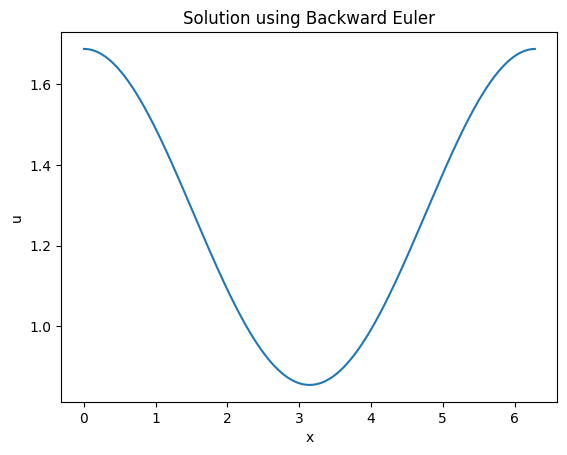

In [11]:
# calling the backward euler function to calculate solution
ut0_be = BE(u0, dt, nt_max, N, kx) 

plt.figure()
ut0_be = np.concatenate((ut_be[N//2:], ut_be[:N//2]))
xt_be = np.linspace(0, L, N)
plt.plot(xt_be, np.real(ut0_be))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution using Backward Euler')
plt.show()



### Crank- Nicholson

In [12]:
# defining the Backward euler method
def Crank_Nicolson(u0, dt, num_tsteps, N, kx):

    # fourier transform of inital condition
    u_fourier = np.fft.fft(u0)

    # defining the coefficient for BE for given problem
    def coefficient_cn(dt, k):
        return (2 -  dt * k**2) /(2 +  dt * k**2)
    
    for i in range(num_tsteps):
        for k in range(N):
            u_fourier[k] = coefficient_cn(dt, kx[k]) * u_fourier[k] 

    # taking inverse fourier transform to obtain the solution
    ut = np.fft.ifft(u_fourier)        

    return ut  

In [13]:
# defining the parameters for calculation of exact solution 
T = 1              # length of time domain
L = 2 * np.pi      # length of spatial domain
N = 1024           # number of spectral points
nt_max = 100       # discretization points of time domain for approximating exact solution
dt = T / nt_max    # spacing in time domain 
x = np.linspace(-L/2, L/2, N + 1)          # creating spatial points array for fourier transform   
x = x[: -1]                                # removing the last point to keep points equal to N               
kx = (2 * np.pi / L) * np.concatenate((np.arange(0, N // 2), np.arange(-N // 2, 0)))     # calculation of corresponding wave numbers 

u0 = u_initial_e(x)                 # initial condition in fourier space
xt = np.linspace(0, L, N + 1)     # discritized points in real space
xt = xt[:-1]


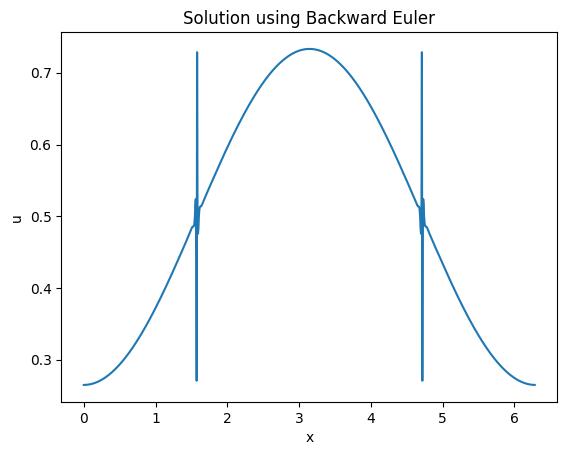

In [14]:
# calling the Crank Nicolson function to calculate solution
ut0_cn = Crank_Nicolson(u0, dt, nt_max, N, kx) 

plt.figure()
ut0_cn = np.concatenate((ut0_cn[N//2:], ut0_cn[:N//2]))
xt_cn = np.linspace(0, L, N)
plt.plot(xt_cn, np.real(ut0_cn))
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution using Backward Euler')
plt.show()
